In [1]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

In [20]:
import mne
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


def TG_matrix_decision(data_ref):
    '''
    Return Temporal Generalization matrix for a classifier trained in the complete time window
    and tested in the complete time window.
    '''

    # Load and decimate epochs
    epochs = mne.read_epochs(data_ref, preload=True, verbose=False).decimate(5)

    # Select present vs absent stim epochs
    max_cat = int(np.max(np.unique(epochs.metadata['snr'])))
    stim_pres_epochs = epochs[str(max_cat)]
    stim_abs_epochs = epochs['1']
    combined_epochs = mne.concatenate_epochs([stim_abs_epochs.copy(), stim_pres_epochs.copy()], verbose=False)

    # Make sure metadata is available
    if combined_epochs.metadata is None or 'blocknumber' not in combined_epochs.metadata.columns:
        raise ValueError("Epochs must have metadata with a 'blocknumber' column.")

    # Define blocks for leave-one-block-out CV
    blocks_train = combined_epochs.metadata['blocknumber'].values
    blocks_test = epochs.metadata['blocknumber'].values
    unique_blocks = np.array([i for i in range(20)]) # np.unique(blocks_test)

    # Define decoding pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler(with_mean=True)),
        ('classifier', LogisticRegression(solver='liblinear', penalty='l2'))])
    
    # Initialize dictionary to store time-series for each category (future output)
    # time_series = {cat: [] for cat in range(max_cat+1)}
    time_series= []

    # Loop over blocks for leave-one-block-out CV
    for block in tqdm(unique_blocks):
        time_series_this_block = []

        # Train and Test EEG time-series
        train_mask = blocks_train != block
        test_mask = blocks_test == block
        data_train = combined_epochs[train_mask].get_data()
        data_test = epochs[test_mask].get_data()

        for time_index in range(data_train.shape[2]):

            # Training EEG snapshots
            X_train = data_train[:, :, time_index]
            y_train = np.where(combined_epochs[train_mask].events[:, 2] == 1, 0, 1)
            pipeline.fit(X_train, y_train)

            # Testing EEG snapshots through time
            for ind_trial, trial in enumerate(data_test):
                ts = np.array(pipeline.decision_function(trial.T))
                if time_index == 0:
                    time_series_this_block.append(ts)
                else:
                    time_series_this_block[ind_trial] = np.vstack((time_series_this_block[ind_trial], ts))

        time_series += time_series_this_block

    # Format time-series as a dictionary with categories as keys and lists of time-series as values
    time_series_dict = {cat: [] for cat in range(max_cat+1)}
    for ind_ts, ts in enumerate(time_series):
        cat = epochs[ind_ts].metadata['snr'].values[0] - 1
        time_series_dict[cat].append(ts)

    # Convert lists to arrays
    time_series = {cat: np.array(series) for cat, series in time_series.items()}

    return time_series_dict


    # Demean and normalize relative to category 0, line-wise
    predictors_demean = {cat: time_series[cat] - np.mean(time_series[0], 0) for cat in time_series.keys()}
    predictors = {int(cat): predictors_demean[cat] / np.std(predictors_demean[0]) for cat in predictors_demean.keys()}

    # del epochs, test_epochs, combined_epochs, stim_pres_epochs, stim_abs_epochs

    # return predictors

In [21]:
data_ref = f'myEpochs_Active/Epoch_{SubIDs[18]}-epo.fif'
epochs_file = cwd.parents[0] / data_ref
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    time_series = TG_matrix_decision(epochs_file)

  0%|          | 0/20 [00:00<?, ?it/s]

In [38]:
# Convert lists to arrays
time_series = {cat: np.array(series) for cat, series in time_series.items()}

In [40]:
time_series[1].shape

(148, 250, 250)

In [50]:
# Demean and normalize relative to category 1
# Ensure keys are ints and all series are arrays
time_series = {int(cat): np.array(series) for cat, series in time_series.items()}
# Remove empty series
time_series = {cat: series for cat, series in time_series.items() if getattr(series, 'size', 0) > 0}
ref_cat = 1
mean_ref = np.mean(time_series[ref_cat], axis=0)

mismatched = [cat for cat, series in time_series.items() if series.shape[1:] != mean_ref.shape]
if mismatched:
    import warnings
    warnings.warn(f"Removing categories with mismatched shapes: {mismatched}")
    for k in mismatched:
        del time_series[k]
    if ref_cat not in time_series:
        raise KeyError(f"Reference category {ref_cat} removed due to mismatch; remaining keys: {list(time_series.keys())}")
    mean_ref = np.mean(time_series[ref_cat], axis=0)
std_ref = np.std(time_series[ref_cat], axis=0)
# Prevent division by zero
std_ref = np.where(std_ref == 0, 1.0, std_ref)
predictors_demean = {cat: series - mean_ref for cat, series in time_series.items()}
predictors = {int(cat): predictors_demean[cat] / std_ref for cat in predictors_demean.keys()}

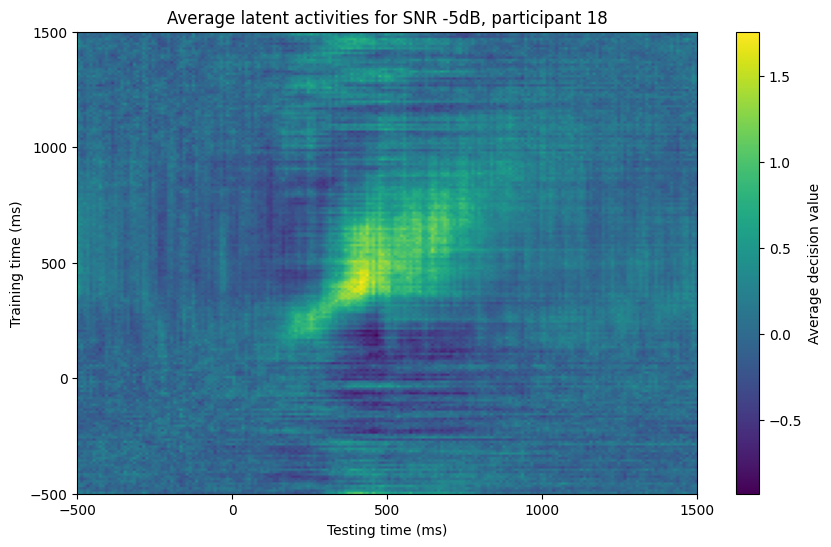

In [75]:
    # plot the heatmap of the average time-series for each category
    from matplotlib.patches import Rectangle
    
    avg_time_series = {cat: np.mean(series, axis=0) for cat, series in predictors.items()}
    
    time_axis = np.linspace(-500, 2000, 250)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    image = ax.imshow(
        avg_time_series[6],
        cmap='viridis',
        origin='lower',
        aspect='auto',
        extent=[time_axis[0], time_axis[-1], time_axis[0], time_axis[-1]],
    )
    
    # ax.axhspan(100, 200, color='white', alpha=0.18)
    # ax.axhspan(300, 500, color='white', alpha=0.18)
    
    # ax.add_patch(Rectangle((100, 100), 100, 100, fill=False, edgecolor='red', linewidth=2))
    # ax.add_patch(Rectangle((300, 300), 200, 200, fill=False, edgecolor='red', linewidth=2))
    
    ax.set_title('Average latent activities for SNR -5dB, participant 18')
    ax.set_xlabel('Testing time (ms)')
    ax.set_ylabel('Training time (ms)')
    ax.set_xlim(-500, 1500)
    ax.set_ylim(-500, 1500)
    ax.set_xticks(np.linspace(-500, 1500, 5))
    ax.set_yticks(np.linspace(-500, 1500, 5))
    fig.colorbar(image, ax=ax, label='Average decision value')
    plt.show()

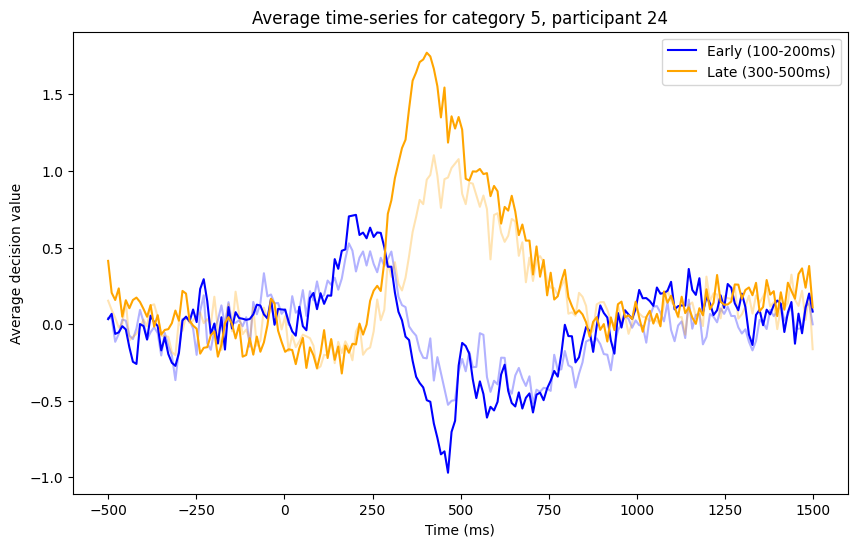

In [74]:
task = 'Active'
file_path = f'Fit_{task}_late'
# os.makedirs(file_path, exist_ok=True)
    
for part in [18]: # tqdm(range(20)):
    
    # Load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train_late = lead.STG(epochs_file, tmin=300, tmax=500)
        state_train_early = lead.STG(epochs_file, tmin=100, tmax=200)
        n_categories = len(list(state_train_late.keys()))
        categories = list(range(n_categories))

# Plot average time-series for category 5 in early and late on the same plot
times = np.linspace(-500,2000,250)
plt.figure(figsize=(10, 6))
# vertical shaded regions for 100-200 ms and 250-500 ms
for cat in [4]:
    plt.plot(times[:200], np.mean(state_train_early[cat], axis=0)[:200], color='blue', alpha=0.3)
    plt.plot(times[:200], np.mean(state_train_late[cat], axis=0)[:200], color='orange', alpha=0.3)
plt.plot(times[:200], np.mean(state_train_early[5], axis=0)[:200], label='Early (100-200ms)', color='blue')
plt.plot(times[:200], np.mean(state_train_late[5], axis=0)[:200], label='Late (300-500ms)', color='orange')
plt.title(f'Average time-series for category 5, participant {SubIDs[part]}')
plt.xlabel('Time (ms)')
plt.ylabel('Average decision value')
plt.legend()
plt.show()